# 1.1. Problem

Assume we have a dataset $\left\{(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)\right\}$ of points in the 2d plane, and we want to estimate the following linear regression model:

$\hat{y}=w_1x+w_0$

Write the batch gradient descent update for $w_0, w_1$ in terms of $x_1, y_1, x_2, y_2, ..., x_n, y_n$, where the learning rate is $\eta$. 

Numerical application: $(1, 1), (2, -1), (3, 2), \eta = 0.1$

## Solution

The batch gradient descent update looks like this:
$$w\leftarrow w - \eta \nabla_w L(w)$$

The gradient of the loss function is known to be:
$$\nabla_{w}L(w)=\frac1{n}X^T(Xw-y)$$

Add a $1$ column to the matrix to account for $w_0$:

$$X=\begin{pmatrix}1 & x_1 \\ 1 & x_2 \\ ... \\ 1 & x_n\end{pmatrix}$$

$$Xw-y=\begin{pmatrix}1 & x_1 \\ 1 & x_2 \\ ... \\ 1 & x_n\end{pmatrix}\begin{pmatrix}w_0 \\ w_1\end{pmatrix}-\begin{pmatrix}y_1 \\ y_2 \\ ... \\ y_n\end{pmatrix}$$

$$Xw-y=\begin{pmatrix}w_0 + x_1w_1 \\ w_0+x_2w_1 \\ ... \\ w_0 + x_nw_1\end{pmatrix}- \begin{pmatrix}y_1 \\ y_2 \\ ... \\ y_n\end{pmatrix}$$

$$Xw-y=\begin{pmatrix}w_0 + x_1w_1-y_1 \\ w_0+x_2w_1-y_2 \\ ... \\ w_0 + x_nw_1-y_n\end{pmatrix}$$

$$X^T(Xw-y)=\begin{pmatrix}1 & 1 & ... & 1 \\ x_1 & x_2 & ... & x_n\end{pmatrix}\begin{pmatrix}w_0 + x_1w_1-y_1 \\ w_0+x_2w_1-y_2 \\ ... \\ w_0 + x_nw_1-y_n\end{pmatrix}$$

$$X^T(Xw-y)=\begin{pmatrix}w_0+x_1w_1-y_1+w_0+x_2w_1-y_2+...+w_0+x_nw_1-y_n \\ x_1(w_0+x_1w_1-y_1)+x_2(w_0+x_2w_1-y_2)+...+x_n(w_0+x_nw_n-y_n)\end{pmatrix}$$

$$X^T(Xw-y)=\begin{pmatrix}nw_0+w_1(x_1+x_2+...+x_n)-(y_1+y_2+...+y_n)\\w_0(x_1+x_2+...+x_n)+w_1(x_1^2+x_2^2+...+x_n^2)-(x_1y_1+x_2y_2+...+x_ny_n)\end{pmatrix}$$

Finally the right side of the update looks like this:
$$w - \eta\frac1{n}\begin{pmatrix}nw_0+w_1(x_1+x_2+...+x_n)-(y_1+y_2+...+y_n)\\w_0(x_1+x_2+...+x_n)+w_1(x_1^2+x_2^2+...+x_n^2)-(x_1y_1+x_2y_2+...+x_ny_n)\end{pmatrix}$$

$$\begin{pmatrix}w_0\\w_1\end{pmatrix} - \eta\frac1{n}\begin{pmatrix}nw_0+w_1(x_1+x_2+...+x_n)-(y_1+y_2+...+y_n)\\w_0(x_1+x_2+...+x_n)+w_1(x_1^2+x_2^2+...+x_n^2)-(x_1y_1+x_2y_2+...+x_ny_n)\end{pmatrix}$$

$$\begin{pmatrix}w_0 - \frac{\eta}{n}(nw_0+w_1(x_1+x_2+...+x_n)-(y_1+y_2+...+y_n))\\w_1-\frac{\eta}{n}(w_0(x_1+x_2+...+x_n)+w_1(x_1^2+x_2^2+...+x_n^2)-(x_1y_1+x_2y_2+...+x_ny_n))\end{pmatrix}$$

So the update per parameter is:
$$w_0\leftarrow w_0 - \frac{\eta}{n}(nw_0+w_1(x_1+x_2+...+x_n)-(y_1+y_2+...+y_n))$$
$$w_1\leftarrow w_1-\frac{\eta}{n}(w_0(x_1+x_2+...+x_n)+w_1(x_1^2+x_2^2+...+x_n^2)-(x_1y_1+x_2y_2+...+x_ny_n))$$

The numerical application:
$$x_1+...+x_n=1+2+3=6$$
$$y_1+...+y_n=1-1+2=2$$
$$x_1^2+...+x_n^2=1^2+2^2+3^2=14$$
$$x_1y_1+...+x_ny_n=1\cdot1+2\cdot(-1)+3\cdot2=1-2+6=5$$

Substituting in the update:
$$w_0\leftarrow w_0 - \frac{0.1}{3}(3w_0+6w_1-2)$$
$$w_1\leftarrow w_1-\frac{0.1}{3}(6w_0+14w_1-5)$$

$$w_0\leftarrow w_0 - 0.1w_0-0.2w_1+\frac{0.2}3$$
$$w_1\leftarrow w_1-0.2w_0-\frac{1.4}3w_1+\frac{0.5}3$$

$$w_0\leftarrow 0.9w_0-0.2w_1+\frac{0.2}3$$
$$w_1\leftarrow -0.2w_0+(1-\frac{1.4}3)w_1+\frac{0.5}3$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
steps = 10000

In [18]:
w0 = 0
w1 = 0
for _ in range(steps):
  w0 = 0.9*w0-0.2*w1+0.2/3
  w1 = -0.2*w0+(1-1.4/3)*w1+0.5/3
w0, w1

(-0.3333333333333314, 0.4999999999999991)

In [19]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [20]:
X = np.array([[1], [2], [3]])
y = np.array([1, -1, 2])

In [21]:
lr.fit(X, y)

LinearRegression()

In [24]:
lr.intercept_, lr.coef_

(-0.3333333333333336, array([0.5]))

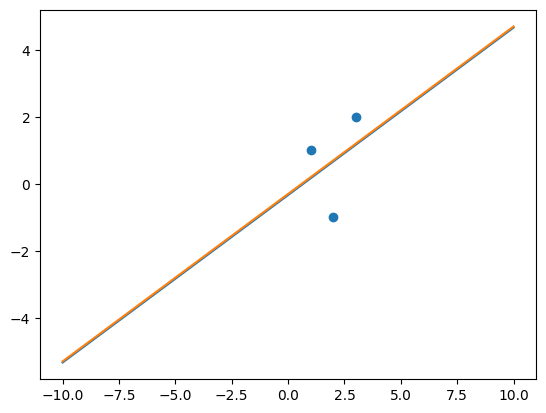

In [23]:
plt.scatter([1, 2, 3], [1, -1, 2])
x = np.linspace(-10, 10, 1000)
y = w0+w1*x
y2 = -0.3 + 0.5*x
plt.plot(x, y)
plt.plot(x, y2)

# 1.2. Problem

Assume we have a dataset $\{(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)\}$ of points in the 2D plane, and we want to estimate the following linear regression model:
$$\hat{y}=w_1x+w_0$$
Compute $w_0, w_1$ in terms of $x_1, y_1, ..., x_n, y_n$. Numerical application:

$$(1, 1), (2, -1), (3, 2)$$

## Solution:

The optimal value of $w$ is:
$$w^*=(X^TX)^{-1}X^Ty$$

We need to add one extra column of $1$'s to $X$, corresponding to the bias, $w_0$:

$$X=\begin{pmatrix}1 & x_1 \\ 1 & x_2 \\ ... \\ 1 & x_n\end{pmatrix}$$
$$y=\begin{pmatrix}y_1 \\ y_2 \\ ... \\ y_n\end{pmatrix}$$

We will assume the matrix $X^TX$ is non-singular, so we can find its inverse. Otherwise we would have to use SVD to approximate $(X^TX)^{-1}X^T$. First, we will compute $X^TX$:

$$X^TX=\begin{pmatrix}1 & 1 & ... & 1 \\ x_1 & x_2 & ... & x_n\end{pmatrix}\begin{pmatrix}1 & x_1 \\ 1 & x_2 \\ ... \\ 1 & x_n\end{pmatrix}$$

$$X^TX=\begin{pmatrix}1+1+...+1 & x_1+x_2+...+x_n \\ x_1+x_2+...+x_n & x_1^2+x_2^2+...+x_n^2\end{pmatrix}$$

Denoting the sums by $S_1$ and $S_2$:

$$X^TX=\begin{pmatrix}n & S_1 \\ S_1 & S_2\end{pmatrix}$$

The determinant is:
$$\det(X^TX)=nS_2-S_1^2$$

The inverse of $X^TX$ is:
$$(X^TX)^{-1}=\frac1{nS_2-S_1^2}\begin{pmatrix}S_2 & -S_1 \\ -S_1 & n\end{pmatrix}$$

Next we compute the product $X^Ty$:
$$X^Ty=\begin{pmatrix}1 & 1 & ... & 1 \\ x_1 & x_2 & ... & x_n\end{pmatrix}\begin{pmatrix}y_1 \\ y_2 \\ ... \\ y_n\end{pmatrix}$$

$$X^Ty=\begin{pmatrix}y_1+y_2+...+y_n \\ x_1y_1+x_2y_2+...+x_ny_n\end{pmatrix}$$

Denoting the sums by $S_3$ and $S_4$:
$$X^Ty=\begin{pmatrix}S_3 \\ S_4\end{pmatrix}$$

The final product is:
$$(X^TX)^{-1}X^Ty=\frac1{nS_2-S_1^2}\begin{pmatrix}S_2 & -S_1 \\ -S_1 & n \end{pmatrix}\begin{pmatrix}S_3 \\ S_4\end{pmatrix}$$

$$(X^TX)^{-1}X^Ty=\frac1{nS_2-S_1^2}\begin{pmatrix}S_2S_3-S_1S_4 \\ -S_1S_3+nS_4\end{pmatrix}$$

$$(X^TX)^{-1}X^Ty=\begin{pmatrix}\frac{S_2S_3-S_1S_4}{nS_2-S_1^2} \\ \frac{-S_1S_3+nS_4}{nS_2-S_1^2}\end{pmatrix}$$

$$w^*=\begin{pmatrix}\frac{S_2S_3-S_1S_4}{nS_2-S_1^2} \\ \frac{-S_1S_3+nS_4}{nS_2-S_1^2}\end{pmatrix}$$

$$\begin{pmatrix}w_0\\w_1\end{pmatrix}^*=\begin{pmatrix}\frac{S_2S_3-S_1S_4}{nS_2-S_1^2} \\ \frac{-S_1S_3+nS_4}{nS_2-S_1^2}\end{pmatrix}$$

$$w_0^*=\frac{S_2S_3-S_1S_4}{nS_2-S_1^2}=\frac{(x_1^2+x_2^2+...+x_n^2)\cdot(y_1+y_2+..+y_n) - (x_1+x_2+...+x_n)\cdot(x_1y_1+x_2y_2+...+x_ny_n)}{n(x_1^2+x_2^2+...+x_n^2)-(x_1+x_2+...+x_n)^2}$$

$$w_1^*=\frac{-S_1S_3+nS_4}{nS_2-S_1^2}=\frac{-(x_1+x_2+...+x_n)\cdot(y_1+y_2+...+y_n)+n(x_1y_1+x_2y_2+...+x_ny_n)}{n(x_1^2+x_2^2+...+x_n^2)-(x_1+x_2+...+x_n)^2}$$

Numerical application:
$$S_1=x_1+x_2+x_3=1+2+3=6$$
$$S_2=x_1^2+x_2^2+x_3^2=1^2+2^2+3^2=14$$
$$S_3=y_1+y_2+y_3=1-1+2=2$$
$$S_4=x_1y_1+x_2y_2+x_3y_3=1*1+2*(-1)+3*2=1-2+6=5$$

$$w_0^*=\frac{14\cdot2-6\cdot5}{3\cdot14-6^2}=\frac{28-30}{42-36}=\frac{-2}{6}=-\frac13$$
$$w_1^*=\frac{-6\cdot2+3\cdot5}{3\cdot14-6^2}=\frac{-12+15}{42-36}=\frac{3}{6}=\frac12$$

So the model is:
$$\hat{y}=\frac12x-\frac13$$

In [ ]:
import numpy as np

In [ ]:
X = np.array([[1, 1], [1, 2], [1, 3]])
y = np.array([1, -1, 2])

In [ ]:
w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

In [ ]:
w

array([-0.33333333,  0.5       ])

In [ ]:
X[:, 1]

array([1, 2, 3])

In [ ]:
S1 = np.sum(X[:, 1])

In [ ]:
S2 = np.sum(X[:, 1]**2)

In [ ]:
n = len(X)

In [ ]:
S3 = np.sum(y)

In [ ]:
S4 = np.sum(X[:, 1]*y)

In [ ]:
n, S1, S2, S3, S4

(3, 6, 14, 2, 5)

In [ ]:
w0 = (S2*S3 - S1*S4)/(n*S2-S1**2)

In [ ]:
w1 = (-S1*S3+n*S4)/(n*S2-S1**2)

In [ ]:
w

array([-0.33333333,  0.5       ])

In [ ]:
w0, w1

(-0.3333333333333333, 0.5)

# 2.1. Problem

Assume we have a training set for two class classification in two dimensions that contains seven sample points: points $(1, 1), (2, 2), (3, 1)$ with label $+1$ and points $(4, 5), (5, 7), (6, 5), (7, 7)$ with label $-1$. Which points are the support vectors for a hard-margin SVM?

## Solution

First, we plot the dataset, and its convex hull, to see if it is linearly separable:

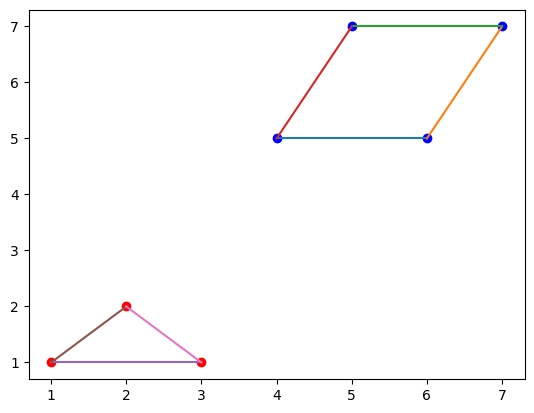

In [ ]:
import matplotlib.pyplot as plt
plt.scatter([1, 2, 3], [1, 2, 1], color = "r")
plt.scatter([4, 5, 6, 7], [5, 7, 5, 7], color = "b")
plt.plot([4, 6], [5, 5])
plt.plot([6, 7], [5, 7])
plt.plot([5, 7], [7, 7])
plt.plot([4, 5], [5, 7])
plt.plot([1, 3], [1, 1])
plt.plot([1, 2], [1, 2])
plt.plot([2, 3], [2, 1])

To draw the convex hulls, imagine a rubber-band stretched around all the points in each set, as tight as possible.

The margin is the minimum distance between these $2$ convex hulls. It is easy to notice that this is the distance between $(2, 2)$ and $(4, 5)$, which is $\sqrt{(4-2)^2+(5-2)^2}=\sqrt{4+9}=\sqrt{13}$.

Now we will see if the points $(2, 2)$ and $(4, 5)$ as support vectors can produce a margin of $\sqrt{13}$. The margins can be described by parallel lines, so their equations can be written as:
$$y = ax + b$$
$$y = ax + c$$

Substituting the points in their respective equations, we get:
$$2 = 2a + b$$
$$5 = 4a + c$$

$$b = 2 - 2a$$
$$c = 5 - 4a$$

The equations become:
$$y = ax + (2 - 2a)$$
$$y = ax + (5 - 4a)$$

The separating line has the equation:
$$y = ax+\frac{2-2a+(5-4a)}{2}$$
$$y = ax+\frac{7-6a}{2}$$

The formula for the distance between lines $y = ax + b$ and $y = ax + c$ is:
$$\frac{|c - b|}{\sqrt{1 + a^2}}$$

For our lines:
$$\frac{|5-4a-2+2a|}{\sqrt{1+a^2}}$$

$$\frac{|3 - 2a|}{\sqrt{1+a^2}}$$

Assuming that $3-2a \geq 0$, the distance becomes:
$$\frac{3-2a}{\sqrt{1+a^2}}$$

$$\frac{3-2a}{\sqrt{1+a^2}}=\sqrt{13}$$

$$\frac{9+4a^2-12a}{1+a^2}=13$$

$$9+4a^2-12a=13+13a^2$$

$$9a^2+12a+4=0$$

$$\Delta = 12^2-4\cdot4\cdot9=144 - 16\cdot9=0$$
$$a_{1, 2}=\frac{-12}{18}=-\frac{2}3$$

$$y = -\frac23x + \frac{7-6(-\frac23)}{2}$$

$$y = -\frac23x + \frac{7+4}2$$
$$y = -\frac23x + \frac{11}2$$

If this line separates the points, then we have proved that the points $(2, 2)$ and $(4, 5)$ are the support vectors.

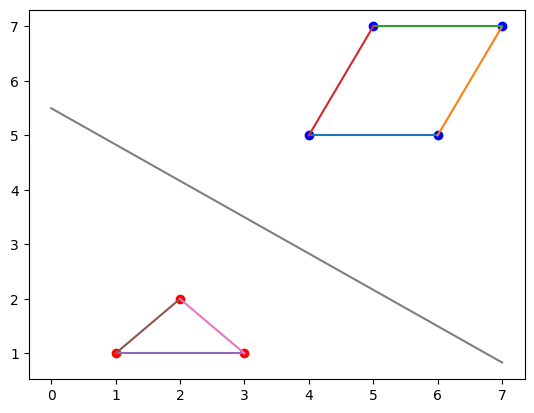

In [ ]:
import matplotlib.pyplot as plt
plt.scatter([1, 2, 3], [1, 2, 1], color = "r")
plt.scatter([4, 5, 6, 7], [5, 7, 5, 7], color = "b")
plt.plot([4, 6], [5, 5])
plt.plot([6, 7], [5, 7])
plt.plot([5, 7], [7, 7])
plt.plot([4, 5], [5, 7])
plt.plot([1, 3], [1, 1])
plt.plot([1, 2], [1, 2])
plt.plot([2, 3], [2, 1])
x = torch.tensor([0, 7])
y = -2/3*x+11/2
plt.plot(x, y)

Visually, the only other point that could also end up on the margins is $(3, 1)$, but we can see the line between $(2, 2)$ and $(3, 1)$ has a slightly different slope to the separating line.

In [7]:
from sklearn.svm import LinearSVC
import numpy as np

X = np.array([[1, 1], [2, 2], [3, 1], [4, 5], [5, 7], [6, 5], [7, 7]])
y = np.array([1, 1, 1, -1, -1, -1, -1])
svc = SVC(kernel = "linear", C = 10**10)
svc.fit(X, y)
svc.support_vectors_

array([[4., 5.],
       [2., 2.]])

# 2.2. Problem

Assume we have a training set for two-class classification in one dimension that contains $3$ sample points: point $x^{(1)}=3$ with label $y^{(1)}=1$, point $x^{(2)}=1$ with label $y^{(2)}=1$, and point $x^{(3)}=-1$ with label $y^{(3)}=-1$. What are the values of $w$ and $b$ given by a hard margin SVM?

## Solution

First plot the points to see if they are linearly separable:

In [ ]:
import matplotlib.pyplot as plt

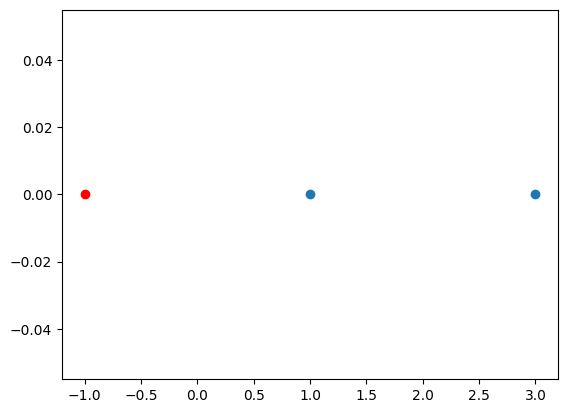

In [ ]:
plt.scatter([3, 1], [0, 0])
plt.scatter([-1], [0], color = "r")
plt.scatter([-1, -1])

Obviously the points are linearly separable. They are separated by a plane with the equation $ax+b=0$, which is esentially a single point.

It's obvious this point has to be between $x=-1$ an d $x=1$, otherwise it wouldn't actually separate the points.

The support vectors are obviously $x=-1$ and $x=1$.

Since this is a $1$-dimensional problem, the equations of the margins are $x=-1$ and $x=1$.

Since the margins are equal in distance from the separating plane, the equation of the separating plane has to be $x = 0$.

This equation can be written as $1\cdot x+0+0$, so $w=1$ and $b=0$.

In [ ]:
from sklearn.svm import LinearSVC
import numpy as np

In [ ]:
svc = LinearSVC(C = 10**10)

In [ ]:
X = np.array([[-1], [1], [3]])
y = np.array([-1, 1, 1])

In [ ]:
svc.fit(X, y)

LinearSVC(C=10000000000)

In [ ]:
svc.coef_, svc.intercept_

(array([[1.]]), array([0.]))

# 3. Problem


Consider training a classification decision tree given a design matrix $X=\begin{pmatrix}6 & 3\\2&7\\9&6\\4&2\end{pmatrix}$ and labels $y=\begin{pmatrix}1\\0\\1\\0\end{pmatrix}$. Let $x_1$ denote feature $1$, corresponding to the first column of $X$ and let $x_2$ denote feature $2$, corresponding to the second column of $X$. Which of the following splits at the root node gives the smallest entropy: $x_1>2$, $x_1>4$, $x_2>3$, $x_2>6$? Motivate your answer.

## Solution

Notice that the split $x_1>4$ perfectly divides the examples, because nodes for which $x_1>4$ belong to class $0$, while nodes for which $x_1\leq4$ belong to class $0$. Therefore each resulting node will have an entropy of $-0\log0-1\log1=0$, so the split itself has an entropy of $0$. 

Entropy is non-negative($\geq0$), therefore this split achieves the smallest entropy. It's also easy to see none of the other options are able to divide the dataset perfectly, so this is the only split that achieves $0$ entropy.

So the minimum entropy is achieved for the split $x_1>4$.

In [ ]:
X = np.array([[6, 3], [2, 7], [9, 6], [4, 2]])
y = np.array([1, 0, 1, 0])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion = "entropy")
clf.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
clf.tree_

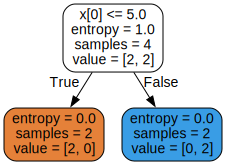

In [ ]:
import os
from graphviz import Source
from sklearn.tree import export_graphviz

export_graphviz(
        clf,
        out_file=os.path.join(".", "tree.dot"),
        rounded=True,
        filled=True
    )

Source.from_file(os.path.join(".", "tree.dot"))

# 4.1. Problem

Assume we have the design matrix:
$$X = \begin{pmatrix}1&0\\0&1\\-1&-1\end{pmatrix}$$

Use PCA to reduce the dimension from $2$ to $1$, i.e., to compute the first principal component.

## Solution

First step in applying PCA is to center the data. Computing the mean of the data:
$$\bar{x} = \frac{(1, 0) + (0, 1) + (-1, -1)}3 = (0, 0)$$

Since the mean is $0$, the data is already centered. To apply PCA we need to find the eigenvalues and eigenvectors of the covariance matrix.

$$\Sigma = \frac1{n}X^TX$$

$$\Sigma = \frac1{n}\begin{pmatrix}1&0&-1\\0&1&-1\end{pmatrix}\begin{pmatrix}1&0\\0&1\\-1&-1\end{pmatrix}$$

$$\Sigma = \frac1{n}\begin{pmatrix}1+0+1 & 0+0+1\\0+0+1 & 0+1+1\end{pmatrix}$$

$$\Sigma = \frac1{3}\begin{pmatrix}2 & 1\\1 & 2\end{pmatrix}$$

$$\Sigma = \begin{pmatrix}\frac23 & \frac13\\\frac13 & \frac23\end{pmatrix}$$

We find the eigenvalues and eigenvectors from their definitions. To find the eigenvalues, the following equation needs to be solved:
$$\det(\Sigma - \lambda I_2) = 0$$

$$\det(\begin{pmatrix}\frac23 & \frac13\\\frac13 & \frac23\end{pmatrix} - \begin{pmatrix}\lambda & 0\\0 & \lambda\end{pmatrix}) = 0$$

$$\det\begin{pmatrix}\frac23-\lambda & \frac13\\\frac13 & \frac23-\lambda\end{pmatrix} = 0$$

$$(\frac23-\lambda)^2-\frac19=0$$

$$(\frac23-\lambda)^2=\frac19$$

$$\frac23-\lambda = \pm\frac13$$

$$-\lambda = -\frac13, -1$$
$$\lambda = \frac13, 1$$

The first principal component is obtained using the eigenvector corresponding to the largest eigenvalue, which is $1$. The next step is to find the eigenvectors corresponding to $\lambda = 1$, by solving the following equation:

$$(\Sigma - \lambda I_2)\cdot\begin{pmatrix}x_1\\x_2\end{pmatrix}=\begin{pmatrix}0\\0\end{pmatrix}$$

$$\begin{pmatrix}\frac23-\lambda & \frac13\\\frac13 & \frac23-\lambda\end{pmatrix}\cdot\begin{pmatrix}x_1\\x_2\end{pmatrix}=\begin{pmatrix}0\\0\end{pmatrix}$$

$$\begin{pmatrix}\frac23-1 & \frac13\\\frac13 & \frac23-1\end{pmatrix}\cdot\begin{pmatrix}x_1\\x_2\end{pmatrix}=\begin{pmatrix}0\\0\end{pmatrix}$$

$$\begin{pmatrix}-\frac13 & \frac13\\\frac13 & -\frac13\end{pmatrix}\cdot\begin{pmatrix}x_1\\x_2\end{pmatrix}=\begin{pmatrix}0\\0\end{pmatrix}$$

$$\begin{pmatrix}-\frac13x_1+\frac13x_2\\\frac13x_1-\frac13x_2\end{pmatrix}=\begin{pmatrix}0\\0\end{pmatrix}$$

We obtain the following $2$ equations:
$$-\frac13x_1+\frac13x_2=0$$
$$\frac13x_1-\frac13x_2=0$$

The second equation is the first multiplied by $-1$. Dividing the first by $\frac13$:
$$-x_1+x_2=0$$

$$x_1=x_2$$

It follows that the eigenvectors corresponding to eigenvalue $1$ are of the form:
$$x=\begin{pmatrix}x_1 \\ x_1\end{pmatrix}$$

PCA requires orthonormal vectors. This means the dot product between any $2$ such vectors has to be $0$, and their norm has to be $1$. Since we only need the first principal component, it is enough to ensure that the vector is of unit norm. This is done by diving the vector by its norm, and if needed giving a particular value to $x_1$:


$$||x||=\sqrt{x_1^2+x_1^2}=|x_1|\sqrt{2}$$

By taking $x_1=1$, and dividing by the norm, we obtain the following principal component:

$$x=\begin{pmatrix}\frac1{\sqrt2} \\ \frac1{\sqrt2}\end{pmatrix}$$

In [3]:
from sklearn.decomposition import PCA
import numpy as np

In [5]:
X = np.array([[1, 0], [0, 1], [-1, -1]])
pca = PCA(n_components = 1)
pca.fit(X)
pca.components_

array([[-0.70710678, -0.70710678]])

# 4.2. Problem

Assume we have the design matrix:
$$X = \begin{pmatrix}6 & -4 \\ -3 & 5 \\ -2 & 6 \\ 7 & -3\end{pmatrix}$$

Use PCA to reduce the dimension from $2$ to $1$ i.e. to compute the first principal component. Observe that $X$ is not centered.

## Solution

The first step when applying PCA is to center the design matrix. We compute the mean of the date:
$$\bar{x}=\frac{(6, -4)+(-3, 5)+(-2, 6)+(7, -3)}{4}$$
$$\bar{x}=(2, 1)$$

Now we obtain the centered design matrix by subtracting the mean from each of its rows:
$$\bar{X}=\begin{pmatrix}4 & -5 \\ -5 & 4 \\ -4 & 5 \\ 5 & -4\end{pmatrix}$$

Next step is computing the covariance matrix:
$$\Sigma=\frac1{n}\bar{X}^T\bar{X}=\frac1{n}\begin{pmatrix}4 & -5 & -4 & 5 \\ -5 & 4 & 5 & -4 \end{pmatrix}\begin{pmatrix}4 & -5 \\ -5 & 4 \\ -4 & 5 \\ 5 & -4 \end{pmatrix}$$

$$\Sigma = \frac14\begin{pmatrix}82 & -80 \\ -80 & 82\end{pmatrix}$$

$$\Sigma = \begin{pmatrix}\frac{41}2 & -20 \\ -20 & \frac{41}{2}\end{pmatrix}$$

The first principal component is the eigenvector of the data covariance matrix that has the largest eigenvalue. We find the eigenvalues from the definition:

$$\det(\Sigma - \lambda I_2)=0$$

$$\det(\begin{pmatrix}\frac{41}2-\lambda & -20 \\ -20 & \frac{41}2 - \lambda\end{pmatrix}) = 0$$

$$(\frac{41}2-\lambda)^2-20^2=0$$

$$\frac{41}{2}-\lambda = \pm 20$$

$$-\lambda \in \left\{-20-\frac{41}2, 20-\frac{41}2\right\}$$

$$\lambda \in \left\{20+\frac{41}2, -20+\frac{41}2\right\}$$

We'll use the first eigenvalue since it is the largest. Let's find the eigenvectors associated with it, from the definition:
$$(\Sigma - \lambda I_2)x=0$$

$$\begin{pmatrix}\frac{41}{2}-20-\frac{41}2 & -20 \\ -20 & \frac{41}{2} - 20 - \frac{41}2\end{pmatrix}\begin{pmatrix}x_1 \\ x_2\end{pmatrix}=\begin{pmatrix}0 \\ 0\end{pmatrix}$$

$$\begin{pmatrix}-20 & -20 \\ -20 & -20\end{pmatrix}\begin{pmatrix}x_1 \\ x_2\end{pmatrix}=\begin{pmatrix}0 \\ 0\end{pmatrix}$$

$$-20x_1-20x_2=0$$

$$x_2=-x_1$$

So the eigenvector is of the form:
$$\begin{pmatrix}x_1 \\ -x_1\end{pmatrix}$$

We have to use orthonormal eigenvectors as principal component, so the dot product between them needs to be $0$ and their norm must be $1$. Since there's only $1$ principal component, the first requirement is satisfied. To obtain an eigenvector of unitary norm, we can divide the general form by its norm, and if needed give a particular value to $x_1$. The norm is:
$$\sqrt{x_1^2+(-x_1)^2}=|x_1|\sqrt{2}$$

By taking $x_1=1$ and dividing by the norm we obtain the following principal component:
$$\begin{pmatrix}\frac1{\sqrt{2}} \\ -\frac1{\sqrt2}\end{pmatrix}$$

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

In [ ]:
X = np.array([[6, -4], [-3, 5], [-2, 6], [7, -3]])
pca = PCA(n_components = 1)
pca.fit(X)

PCA(n_components=1)

In [ ]:
pca.components_

array([[-0.70710678,  0.70710678]])

# 5.1. Problem

Consider a dataset containing six one-dimensional points: $\left\{2, 4, 7, 8, 12, 14\right\}$. After three iterations of hierarchical clustering using Euclidian distance between points, we get the $3$ clusters: $C_1=\left\{2, 4\right\}$, $C_2=\left\{7, 8\right\}$, $C_3=\left\{12, 14\right\}$. What is the distance between clusters $C_1$ and $C_2$ using single linkage? What is the distance between clusters $C_1$ and $C_2$ using complete linkage?

## Solution

Single linkage distance computes the distance as the shortest distance between any $2$ elements of the clusters. By inspection it is noticed that the shortest distance is between $4$ and $7$. This distance is $7-4=3$.

Complete linkage distance computes the distance as the longest distance between any $2$ elements of the clusters. By inspection we can see this distance is $8-2=6$.

# 5.2. Problem

Assume we have to cluster $7$ points into $3$ clusters using the $K$-means clustering algorithm. Suppose after the first iteration, clusters $C_1$, $C_2$ and $C_3$ contain the following two-dimensional points:

$a)$ $C_1$ contains the $2$ points: $\left\{(0, 6), (6, 0)\right\}$

$b)$ $C_2$ contains the $3$ points: $\left\{(2, 2), (4, 4), (6, 6)\right\}$

$c)$ $C_3$ contains the $2$ points: $\left\{(5, 5), (7, 7)\right\}$

What are the cluster centers computed for these $3$ clusters?

## Solution

The center of a cluster is the mean of its points. So the center of $C_1$ is $(\frac{0+6}2, \frac{6+0}{2})=(3, 3)$, the center of $C_2$ is $(\frac{2+4+6}{3}, \frac{2+4+6}{3})=(4, 4)$, and the center of $C_3$ is $(\frac{5+7}{2}, \frac{5+7}{2})=(6, 6)$.

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

In [ ]:
kmeans = KMeans(n_clusters = 3)

In [ ]:
X = np.array([[0, 6], [6, 0], [2, 2], [4, 4], [6, 6], [5, 5], [7, 7]])

In [ ]:
kmeans.fit_predict(X)

c:\Users\Claudiu\miniconda3\envs\lv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([1, 0, 0, 2, 2, 2, 2])

In [ ]:
kmeans.cluster_centers_

array([[4. , 1. ],
       [0. , 6. ],
       [5.5, 5.5]])

# 6. Problem

The following graph shows the structure of a simple neural network with a single hidden layer. The input layer consists of three dimensions $x=(x_1, x_2, x_3)$. The hidden layer includes two units $h=(h_1, h_2)$. The output layer includes one unit $y$. We ignore bias terms for simplicity. We use sigmoid $\sigma(z) = \frac1{1+e^{-z}}$ as activation function for the hidden layer and the identity for the output layer. Moreover, denote by $l(y, t)=\frac12(y-t)^2$ the loss function. Here, $t$ is the target value for the output unit $y$. Denote by $W$ and $V$ weight matrices connecting input and hidden layer, and hidden layer and output, respectively. Compute symbolically $\frac{\partial l}{\partial W}$. Numerical application:
$$W=\begin{pmatrix}1 & 0 & 1 \\ 1 & -1 & 0\end{pmatrix}, V=\begin{pmatrix}0 & 1\end{pmatrix}, x = (1, 2, 1), t = 1$$

<img src = " 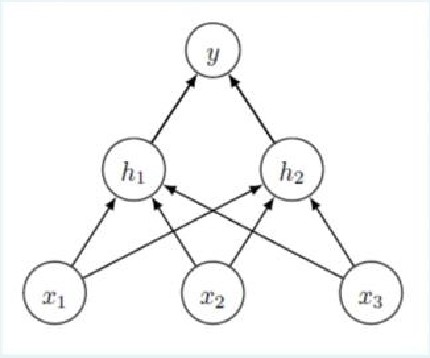">

## Solution

$$l(y, t)=\frac12(y-t)^2$$

$$l(y, t)=\frac12(h_1v_1+h_2v_2-t)^2$$

$$l(y, t)=\frac12(v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)^2$$

We view $x$ as a column-vector.

Computing the derivative with respect to $w_{11}$:
$$\frac{\partial l}{\partial w_{11}} = 2\cdot\frac12(v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)\frac{\partial}{\partial w_{11}}(v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)$$

$$\frac{\partial l}{\partial w_{11}} = (v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)(\frac{\partial}{\partial w_{11}}(v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13}))+\frac{\partial}{\partial w_{11}}(v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23})) - \frac{\partial}{\partial w_{11}}(t))$$

$$\frac{\partial l}{\partial w_{11}} = (v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)(\frac{\partial}{\partial w_{11}}(v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})))$$

$$\frac{\partial l}{\partial w_{11}} = (v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)(v_{1}\sigma'(x_1w_{11}+x_2w_{12}+x_3w_{13})\frac{\partial}{\partial w_{11}}(x_1w_{11}+x_2w_{12}+x_3w_{13}))$$

$$\frac{\partial l}{\partial w_{11}} = (v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)(v_{1}\sigma'(x_1w_{11}+x_2w_{12}+x_3w_{13})x_1)$$

It is known that the derivative of $\sigma(x)$ is $\sigma(x)(1-\sigma(x))$:

$$\frac{\partial l}{\partial w_{11}} = (v_1\cdot\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})+v_2\cdot\sigma(x_1w_{21}+x_2w_{22}+x_3w_{23}) - t)(v_{1}x_1\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})(1-\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})))$$

We can simply the first paranthesis, denoting by $W_1$ the first row of the matrix $W$ as a row-vector:

$$\frac{\partial l}{\partial w_{11}} = (v_1\cdot\sigma(W_{1}\cdot x)+v_2\cdot\sigma(W_2\cdot x) - t)(v_{1}x_1\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})(1-\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})))$$

$$\frac{\partial l}{\partial w_{11}} = (V\cdot\sigma(W\cdot x)-t)(v_{1}x_1\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})(1-\sigma(x_1w_{11}+x_2w_{12}+x_3w_{13})))$$

$$\frac{\partial l}{\partial w_{11}} = (V\cdot\sigma(W\cdot x)-t)(v_{1}x_1\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)))$$

The sigma function is apply element wise.

Similarly:

$$\frac{\partial l}{\partial w_{12}} = (V\cdot\sigma(W\cdot x)-t)(v_{1}x_2\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)))$$

$$\frac{\partial l}{\partial w_{13}} = (V\cdot\sigma(W\cdot x)-t)(v_{1}x_3\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)))$$

$$\frac{\partial l}{\partial w_{21}} = (V\cdot\sigma(W\cdot x)-t)(v_{2}x_1\sigma(W_2\cdot x)(1-\sigma(W_2\cdot x)))$$

$$\frac{\partial l}{\partial w_{22}} = (V\cdot\sigma(W\cdot x)-t)(v_{2}x_2\sigma(W_2\cdot x)(1-\sigma(W_2\cdot x)))$$

$$\frac{\partial l}{\partial w_{23}} = (V\cdot\sigma(W\cdot x)-t)(v_{2}x_3\sigma(W_2\cdot x)(1-\sigma(W_2\cdot x)))$$

The first term is a real number, the same for all derivatives. We organize the derivatives in a matrix, pulling that term outside:
$$(V\cdot\sigma(W\cdot x) - t)\cdot\begin{pmatrix}v_{1}x_1\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)) & v_{1}x_2\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)) & v_{1}x_1\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)) \\ v_{2}x_1\sigma(W_2\cdot x)(1-\sigma(W_2\cdot x)) & v_{2}x_2\sigma(W_2\cdot x)(1-\sigma(W_2\cdot x)) & v_{2}x_3\sigma(W_2\cdot x)(1-\sigma(W_2\cdot x))\end{pmatrix}$$

$$(V\cdot\sigma(W\cdot x) - t)\begin{pmatrix}v_{1}\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)) \\ v_{2}\sigma(W_2\cdot x)(1-\sigma(W_2\cdot x))\end{pmatrix}\cdot\begin{pmatrix}x_1 & x_2 & x_3\end{pmatrix}$$

$$(V\cdot\sigma(W\cdot x) - t)(V^T\circledcirc \begin{pmatrix}\sigma(W_1\cdot x)(1-\sigma(W_1\cdot x)) \\ \sigma(W_2\cdot x)(1-\sigma(W_2\cdot x))\end{pmatrix})x^T$$

$$(V\cdot\sigma(W\cdot x) - t)(V^T\circledcirc \sigma(W\cdot x)\circledcirc(1-\sigma(W\cdot x))x^T$$

Finally, the numerical application:
$$Wx = \begin{pmatrix}1 & 0 & 1 \\ 1 & -1 & 0\end{pmatrix}\cdot \begin{pmatrix}1 \\ 2 \\ 1\end{pmatrix}$$

$$Wx = \begin{pmatrix}2 \\ -1\end{pmatrix}$$

$$\sigma(Wx) = \begin{pmatrix}\sigma(2) \\ \sigma(-1)\end{pmatrix}$$

$$\sigma(Wx) = \begin{pmatrix}0.88 \\ 0.27\end{pmatrix}$$

$$V^T\circledcirc\sigma(Wx)\circledcirc(1-\sigma(Wx)=\begin{pmatrix}0 \\ 1\end{pmatrix}\circledcirc\begin{pmatrix}0.88 \\ 0.27\end{pmatrix}\circledcirc\begin{pmatrix}0.12 \\ 0.73\end{pmatrix} = \begin{pmatrix}0 \\ 0.197\end{pmatrix}$$

$$V\cdot\sigma(W\cdot x)=\begin{pmatrix}0 & 1\end{pmatrix}\cdot \begin{pmatrix}0.88 \\ 0.27\end{pmatrix} = 0.27$$

$$(0.27 - 1)\begin{pmatrix}0 \\ 0.197\end{pmatrix}\cdot\begin{pmatrix}1 & 2 & 1\end{pmatrix}$$

$$-0.73\begin{pmatrix}0 \\ 0.197\end{pmatrix}\cdot\begin{pmatrix}1 & 2 & 1\end{pmatrix}$$

$$\begin{pmatrix}0 \\ -0.144\end{pmatrix}\cdot\begin{pmatrix}1 & 2 & 1\end{pmatrix}$$

$$\begin{pmatrix}0 & 0 & 0 \\ -0.144 & -0.288 & -0.144\end{pmatrix}$$

In [ ]:
x = torch.tensor([[1, 2, 1]], dtype = torch.float).T

In [ ]:
W = torch.tensor([[1, 0, 1], [1, -1, 0]], dtype = torch.float, requires_grad = True)

In [ ]:
V = torch.tensor([[0, 1]], dtype = torch.float)

In [ ]:
h = torch.nn.Sigmoid()(W @ x)

In [ ]:
t = torch.tensor(1, dtype = torch.float)

In [ ]:
y = V @ h

In [ ]:
l = 1/2*(y-t)**2

In [ ]:
l.backward()

In [ ]:
W.grad

tensor([[ 0.0000,  0.0000,  0.0000],
        [-0.1437, -0.2875, -0.1437]])

In [ ]:
(V @ torch.nn.Sigmoid()(W @ x) - t)*(V.T*torch.nn.Sigmoid()(W @ x) * (1-torch.nn.Sigmoid()(W @ x))) @ x.T

tensor([[-0.0000, -0.0000, -0.0000],
        [-0.1437, -0.2875, -0.1437]], grad_fn=<MmBackward0>)

# 7.1. Problem

Assume we have the following CNN classifier:

$\text{INPUT, CONV-9-32, POOL-2, CONV-5-64, POOL-2, CONV-5-64, POOL-2, FC-3}$.

For each layer, calculate the number of weights, number of biases, and the size of the associated feature maps. The size of INPUT is $128\times128\times3$. The notation follows the convention:
 - CONV-K-N denotes a convolutional layer with $N$ filters, each of them of size $K\times K$, padding and stride parameters are always $0$ and $1$, respectively.
 - POOL-K indicates a $K\times K$ pooling layer with stride $K$ and padding $0$.
 - FC-N stands for a fully-connected layer with $N$ neurons.

## Solution

The Conv-9-32 layer takes in $3$ channels and outputs $32$. It does cross correlation between each input layer, adding the outputs and a bias term to produce one output layer. Each output layer needs $3$ filters, one for each input layer. Each of the filters has $9\times9$ weights. The total number of weights is therefore $3\cdot32\cdot9\cdot9=7776$. There is also one bias term per each output layer, so a total of $32$ biases. The size of the image is reduced by the $9\times9$ filters, going from $128\times 128$ to $(128-9+1)\times(128-9+1)=(120, 120)$. Therefore the total size of the feature maps is $120\cdot 120\cdot 32 = 460800$.

The POOL-2 layer takes in the $32$ $120\times120$ channels and outputs $32$ $(\frac{\lfloor 120 - 2 + 2\rfloor}{2} \times \frac{\lfloor 120 - 2 + 2\rfloor}{2}) = (60 \times 60)$. This layer has no parameters. The size of the feature maps is $60\cdot60\cdot32 = 115200$.

The CONV-5-64 layer takes in $32$ channels and outputs $64$ channels. It's filters are $5\times 5$. Therefore the number of weights is $5\cdot5\cdot64\cdot32 = 51200$, and the number of biases is $64$. The size of the image becomes $(60 - 5 + 1\times 60 - 5 + 1) = (56\times 56)$, so the size of the feature maps is $56\cdot56\cdot64 = 200704$.

The POOL-2 layer takes in $64$ channels of size $56\times 56$, and outputs $64$ channels of size $(\frac{\lfloor 56 - 2 + 2\rfloor}{2} \times \frac{\lfloor 56 - 2 + 2\rfloor}{2}) = (28 \times 28)$. This layer has no weights or biases. The size of the feature maps is $28\cdot28\cdot64 = 50176$.

The last CONV-5-64 layer takes in $64$ channels and outputs $64$ channels, applying a $5\times 5$ filter. The number of weights is therefore $5\cdot5\cdot64\cdot64 = 102400$ weights. The number of biases is $64$. The size of the image becomes $(28 - 5 + 1 \times 28 - 5 + 1) = (24 \times 24)$, so the size of the feature maps is $24\cdot 24\cdot 64 = 36864$.

The last POOL-2 layer takes in $64$ channels and outputs $64$ channels. The new image size is $(\frac{\lfloor 24 - 2 + 2\rfloor}{2} \times \frac{\lfloor 24 - 2 + 2\rfloor}{2}) = (12 \times 12)$. Being a Pooling layer, it has no weights or biases. The size of the feature maps is $12\cdot12\cdot64=9216$.

The FC-3 layer has $9216$ inputs and $3$ outputs. Each output uses all inputs, needing $9216$ weights, and $1$ bias. The total number of weights is therefore $9216\cdot3=27648$, and the number of biases is $3$.

In [ ]:
import torch.nn as nn

In [ ]:
model = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=32, kernel_size=9), nn.MaxPool2d(
    kernel_size=2), nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5),
    nn.MaxPool2d(kernel_size=2), nn.Conv2d(
        in_channels=64, out_channels=64, kernel_size=5),
    nn.MaxPool2d(kernel_size=2), nn.Flatten(
        start_dim=0), nn.Linear(in_features=9216, out_features=3)
)


In [ ]:
image = torch.arange(128 * 128 * 3, dtype = torch.float).reshape(3, 128, 128)

In [ ]:
image.shape

torch.Size([3, 128, 128])

In [ ]:
model(image).shape

torch.Size([3])

In [ ]:
with_weights = [nn.Conv2d, nn.Linear]

In [ ]:
image_copy = torch.clone(image)
for layer in model:
  image_copy = layer(image_copy)
  print(f'Feature Map Size {nn.Flatten(start_dim = 0)(image_copy).shape}')
  print(f'Number of output layer {image_copy.shape[0]}')
  print(image_copy.shape)
  if type(layer) in with_weights:
    print(f'Number of weights {nn.Flatten(start_dim = 0)(layer.weight).shape}')
    print(f'Number of biases {layer.bias.shape}')
  print()

Feature Map Size torch.Size([460800])
Number of output layer 32
torch.Size([32, 120, 120])
Number of weights torch.Size([7776])
Number of biases torch.Size([32])

Feature Map Size torch.Size([115200])
Number of output layer 32
torch.Size([32, 60, 60])

Feature Map Size torch.Size([200704])
Number of output layer 64
torch.Size([64, 56, 56])
Number of weights torch.Size([51200])
Number of biases torch.Size([64])

Feature Map Size torch.Size([50176])
Number of output layer 64
torch.Size([64, 28, 28])

Feature Map Size torch.Size([36864])
Number of output layer 64
torch.Size([64, 24, 24])
Number of weights torch.Size([102400])
Number of biases torch.Size([64])

Feature Map Size torch.Size([9216])
Number of output layer 64
torch.Size([64, 12, 12])

Feature Map Size torch.Size([9216])
Number of output layer 9216
torch.Size([9216])

Feature Map Size torch.Size([3])
Number of output layer 3
torch.Size([3])
Number of weights torch.Size([27648])
Number of biases torch.Size([3])



# 7.2. Problem

Assume we have an input image whose shape is $128\times 128\times 3$. Compute the output size and the number of parameters of each of the following possible settings for the first convolutional layer, given the input has the shape described above.

$a)$ The first convolutional layer has a stride of $1$, a filter size of $3$, input padding of $0$ and $64$ filters.

$b)$ The first convolutional layer has a stride of $1$, a filter size of $5$, input padding of $2$ and $16$ filters.

$c)$ The first convolutional layer has a stride of $2$, a filter size of $2$, input padding of $0$ and $32$ filters.

## Solution

The formula for the output shape of a square image of size $n$ after passing through a convolutional layer with filter size $k$, padding of $p$ and stride of $s$ is:
$$\lfloor\frac{n - k + p + s}{s}\rfloor\times \lfloor\frac{n - k + p + s}{s}\rfloor$$

For $a)$, the size becomes:
$$\lfloor\frac{128 - 3 + 0 + 1}{1}\rfloor = 126$$

For $b)$, the size becomes:
$$\lfloor\frac{128 - 5 + 2 + 1}{1}\rfloor = 126$$

For $c), the size becomes:
$$\lfloor\frac{128 - 2 + 0 + 2}{2}\rfloor = 64$$

The number output channels is $64$, then $16$, and then $32$, so the sizes are:
$$126 \times 126 \times 64$$

$$126\times126\times16$$

$$64\times64\times32$$

Considering an image with $n$ input channels and $m$ output channels, we need $n$ kernels for each output channel, since a filter is applied to each input channel, and then the results are added together. Each output channel also requires a bias term. Therefore the total number of kernels is $nm$. For a $k\times k$ kernel, it follows we need a total of $nmk^2$ weights. The number of biases is equal to the number of output channels, so there are also $m$ biases. The total number of parameters is hence $nmk^2+m$.

The number of parameters per option is:
$$3\cdot 64\cdot 3^2 + 64 = 1792$$
$$3\cdot 16\cdot 5^2 + 16 = 1216$$
$$3\cdot 32 \cdot 2^2 + 32 = 416$$

Torch considers `padding = 2` to mean adding $2$ rows/columns of $0$ on all sides, while in the course it means adding a total of $\frac22=1$ row/column of padding on all sides.

In [26]:
import torch
import torch.nn as nn

In [27]:
layers = [nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=0, stride=1),
                    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=1, stride=1),
                    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=2, padding=0, stride=2)]

In [28]:
for layer in layers:
  print(sum([parameter.numel() for parameter in layer.parameters() if parameter.requires_grad]))

1792
1216
416


In [30]:
image = torch.arange(3*128*128, dtype = torch.float).reshape(1, 3, 128, 128)

In [31]:
for layer in layers:
  print(layer(image).shape[1:])

torch.Size([64, 126, 126])
torch.Size([16, 126, 126])
torch.Size([32, 64, 64])


# 8.1. Problem

Compute symbolically the total number of parameters of a GRU layer, knowing that the number of examples is $n$, the number of inputs is $d$, and the number of hidden units is $h$. Numerical application: $n=2, d=3, h=4$.

## Solution

First, the number of examples doesn't matter, since obviously the model has a fixed set of parameters, irrespective of the number of examples in a batch.  

A GRU layer has a reset gate, an update gate, an a hidden state. The gates depend on the input, $X$, and the previous state $H$.

Since the number of hidden units is $h$, and the number of inputs is $d$, and the dependence between the previous and the current gate is in the form of a MLP layer, there are a total of $dh$ weights. The dependence on the previous state requires $h^2$ weights. 

The hidden state update depends on the current input and current state, in the same way as the gates.

Therefore the total amount of weights is $3(dh+h^2)$.

The gates and the hidden state update also have $h$ biases each, in total $3h$.

The total number of parameters is $3(dh+h^2+h)$.

**NOTE**: One can add up the dimensions of the matrices from the GRU section in course $8$.

In [ ]:
n, d, h = 2, 3, 4

In [ ]:
import torch
import torch.nn as nn

In [ ]:
layer = nn.GRU(d, h, 1)

In [ ]:
sum(p.numel() for p in layer.parameters() if p.requires_grad) - 3*h

96

**NOTE**: Torch adds $3$ extra bias vectors, one for the reset gate, update gate, and state update, each of dimension $1\times h$.

# 8.2. Problem

Compute symbolically the total number of parameters (weights and biases) of an LTSM layer, knowing that the number of examples is $n$, the number of inputs is $d$, and the number of hidden units is $h$. Numerical application: $n=2, d=3, h=4$.

## Solution

A LTSM layer has $3$ gates. Each gates needs a $d\times h$ weight matrix for the influence the input has, and a $h\times h$ matrix for the influence the past state has on the gate. It also needs a $1\times h$ bias vector.
The candidate memory cell needs the same amount of weights and biases. Therefore the total number of parameters is:
$$4(dh+h^2+h)$$

Numerical application:
$$4(3\cdot4+4^2+4)=4(12+16+4)=4\cdot32=128$$

In [ ]:
n, d, h = 2, 3, 4

In [ ]:
import torch
import torch.nn as nn

layer = nn.LSTM(d, h)
sum([param.numel() for param in layer.parameters() if param.requires_grad_]) - 4 * h

128

**NOTE**: Torch adds an extra bias vector to each gate and to the candidate state.

# 9.1. Problem

Compute the total number of parameters for additive attention for $n$ queries and $m$ key-value pairs, where queries are of length $q$, keys are of length $k$, and values are of length $v$. Give the answer symbolically. Numerical application:
$n = 2, m = 3, q = k = 2, v = 3$

## Solution

The attention scoring function for additive attention is:
$$a(q, k)=w_v^T\tanh(W_qq+W_kk)$$

The weight matrices have the following dimensions:
$$W_q\in R^{h\times q}, W_k\in R^{h\times k}, w_v\in R^h$$

Here $h$ is a hyper-parameter. Therefore the total number of parameters is:
$$hq+hk+h=h(q+k+1)$$

Numerical application:
$$h(2+2+1)=5h$$

# 9.2. Problem

Assume a scalar multiplication and a scalar addition both account for one FLOP and exponentiation accounts for $10$ FLOPs. All other scalar operations account for $0$ FLOPs. How many FLOPs does the scaled dot-product attention require for $n$ queries and $m$ key-value pairs, where queries and keys are of length $d$ and values are of length $v$. Give the answer symbolically. Numerical application: $n=2,m=3,d=2, v=3$.

## Solution

The formula for the scaled dot-product attention is the following:
$$\text{softmax}(\frac{QK^T}{\sqrt{d}})\cdot V$$

$$Q\in R^{n\times d}, K\in R^{m\times d}$$

$$QK^T=\begin{pmatrix}q_{11} & q_{12} & ... & q_{1d} \\ q_{21} & q_{22} & ... & q_{2d} \\ . \\ . \\ q_{n1} & q_{n2} & ... & q_{nd}\end{pmatrix}\times\begin{pmatrix}k_{11} & k_{21} & ... & k_{m1} \\ k_{12} & k_{22} & ... & k_{m2}\\ . \\ . \\ . \\ k_{1d} & k_{2d} & ... & k_{md}\end{pmatrix}$$

Matrix multiplication is done row by column. Rows of the first matrix, and columns of the second, contain $d$ scalars, so we need to do $k$ multiplications. Since we have $n$ rows in the first matrix, and $m$ columns in the second, the total number of multiplications is $nmd$. For each row by column multiplication, we also have to do $d - 1$ additions, so a total of $(nm(d-1))$ additions.

The square root and the division are for free.

After the matrix product and division we are left with a $n\times m$ matrix. We have to apply the softmax operation $n$ times, one for each row of the matrix.

$$\frac{e^{x_1}}{e^{x_1}+e^{x_2}+...+e^{x_m}}, \frac{e^{x_2}}{e^{x_1}+e^{x_2}+...+e^{x_m}}, ...., \frac{e^{x_m}}{e^{x_1}+e^{x_2}+...+e^{x_m}}$$

To compute the softmax, we need to exponentiate each element in the row, so we have a total of $m$ exponentiations. We also need to add these, leading to $m-1$ additions. Assuming we don't recompute exponentials, and since the division is free, we end up with a total of $mn$ exponentiations and $(m-1)n$ additions.

After applying softmax, we are left with a $n\times m$ matrix, which needs to be multiplied with a $m\times v$ matrix. Like above, this results in $nmv$ multiplications and $n(m-1)v$ additions.

The total amount of multiplications and additions is:
$$nmd+nm(d-1)+(m-1)n+nmv+n(m-1)v$$
The total amount of exponentiations is:
$$mn$$

The flop count is:

$$nmd+nm(d-1)+(m-1)n+nmv+n(m-1)v+10(nm)$$

Numerical application:


$$nmd+nm(d-1)+(m-1)n+nmv+n(m-1)v+10(nm)=12+6+4+18+12+60=112$$